White wine quality EDA

To being we will inspeact the data set so we can find what makes white wine quality become high or low.

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("archive/winequality-white.csv", sep=";")

In [23]:
# View the first 5 rows of the DataFrame
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.0,0.27,0.36,20.7,0.045,45.0,170.0,1.0010,3.00,0.45,8.8,6
1,6.3,0.30,0.34,1.6,0.049,14.0,132.0,0.9940,3.30,0.49,9.5,6
2,8.1,0.28,0.40,6.9,0.050,30.0,97.0,0.9951,3.26,0.44,10.1,6
3,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6
4,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6


In [ ]:
# View information about the DataFrame
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4898 entries, 0 to 4897
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         4898 non-null   float64
 1   volatile acidity      4898 non-null   float64
 2   citric acid           4898 non-null   float64
 3   residual sugar        4898 non-null   float64
 4   chlorides             4898 non-null   float64
 5   free sulfur dioxide   4898 non-null   float64
 6   total sulfur dioxide  4898 non-null   float64
 7   density               4898 non-null   float64
 8   pH                    4898 non-null   float64
 9   sulphates             4898 non-null   float64
 10  alcohol               4898 non-null   float64
 11  quality               4898 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 459.3 KB


In [ ]:
# Inspect the distribution of the 'quality' column
df['quality'].value_counts()

quality
6    2198
5    1457
7     880
8     175
4     163
3      20
9       5
Name: count, dtype: int64

Now that we've viewed the type of data we are working with we can begin exploring it so we can understand what makes white wine quality good or bad. We can inspect it more closely now that we can see that quality is the defining variable since it is the only int variable. 

In [34]:
# View how the variables relate to each other using a correlation matrix
quality_corr = df.corr()["quality"].sort_values()

quality_corr

density                -0.307123
chlorides              -0.209934
volatile acidity       -0.194723
total sulfur dioxide   -0.174737
fixed acidity          -0.113663
residual sugar         -0.097577
citric acid            -0.009209
free sulfur dioxide     0.008158
sulphates               0.053678
pH                      0.099427
alcohol                 0.435575
quality                 1.000000
Name: quality, dtype: float64

From the correlation we can view that density and residual sugar are stronly correlated at .838966, somewhat correlated in total sulfur dioxide and free sulfur dioxide at .615501, somewhat correlated in residual sugar and total sulfur dioxide at .401439, somewhat correlated in density and total sulfur dioxide at .529881, and somewhat correlated in alcohol and quality at .435575.

In [10]:
# View if there are missing values in the DataFrame
df.isnull().sum()

fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64

In [11]:
# View if there are any duplicate rows in the DataFrame
df.duplicated().sum()

np.int64(937)

In [12]:
# View if there are unusual values in the 'quality' column
df['quality'].unique()

array([6, 5, 7, 8, 4, 3, 9])

Now we can begin to inspect the quality distribution of the data

(array([  20.,  163., 1457., 2198.,  880.,  180.]),
 array([3., 4., 5., 6., 7., 8., 9.]),
 <BarContainer object of 6 artists>)

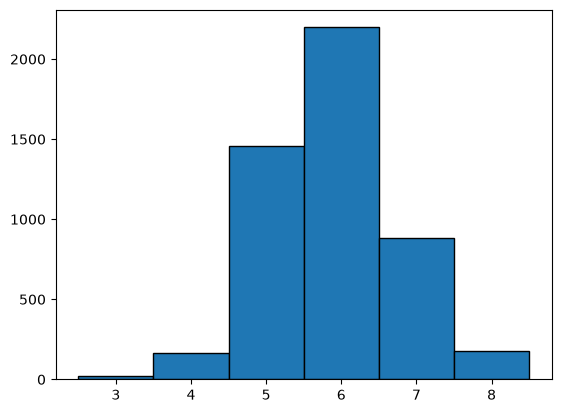

In [13]:
# View the distribution of the 'quality' column using a histogram
plt.hist(df['quality'], bins=range(3, 10), align='left', edgecolor='black')

From what we can see in the histogram we can see that most of the quality distribution is arranged in a quality variable between 5-7. Most of them coming over 2000+ wines rated as a quality of 6.

<Axes: >

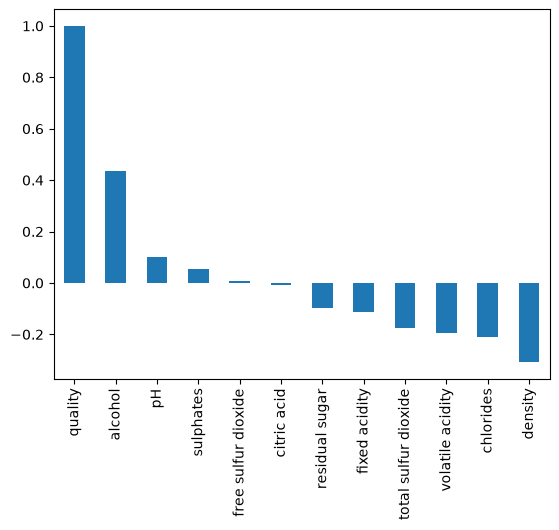

In [27]:
# View the correlation between the 'quality' column and other variables using a bar chart
df.corr()['quality'].sort_values(ascending=False).plot(kind='bar')


Text(0, 0.5, 'Density')

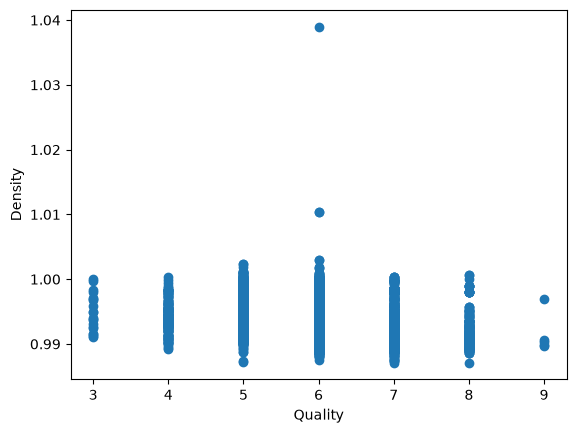

In [ ]:
# Inspect the relationship between 'quality' and 'density' using a scatter plot

plt.scatter(df['quality'], df['density'])
plt.xlabel('Quality')
plt.ylabel('Density')



Text(0, 0.5, 'Alcohol')

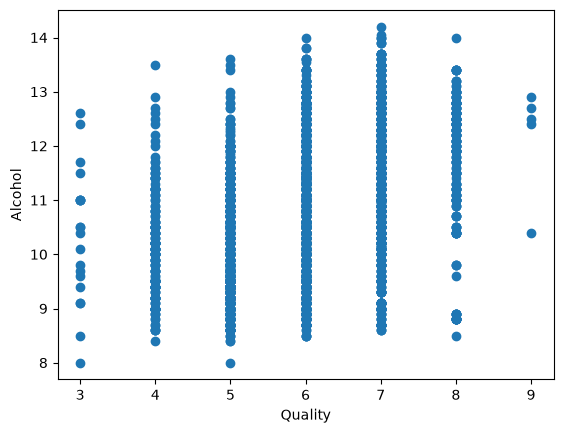

In [30]:
# Inspect the relationship between 'alcohol' and 'quality' using a scatter plot

plt.scatter(df['quality'], df['alcohol'])
plt.xlabel('Quality')
plt.ylabel('Alcohol')

Text(0, 0.5, 'Citric Acid')

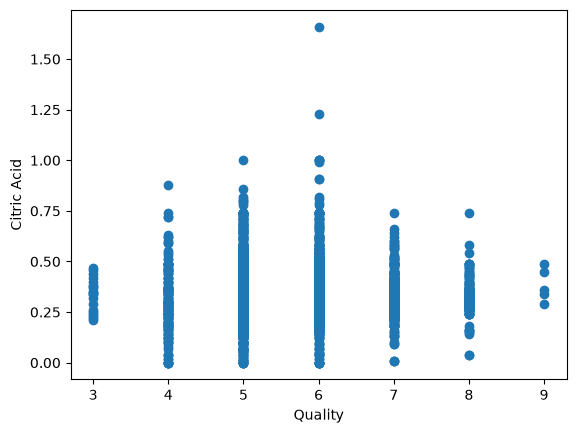

In [33]:
# Inspect the relationship between 'citric acid' and 'quality' using a scatter plot

plt.scatter(df['quality'], df['citric acid'])
plt.xlabel('Quality')
plt.ylabel('Citric Acid')